# Cox PH assumption check (time-varying effects)

Quick diagnostic on the personal 14-day person-interval frame: do covariate
effects stay constant over follow-up time?

For discrete / counting-process data, a practical check is a **discrete-time
logit** (interval hazard) with a feature × time interaction:

`P(event) ~ x + t + x:t`

A significant `x:t` term means the log-odds effect of `x` changes with time —
the same substantive concern as a Cox PH violation. Complementary plot: univariate
log-odds of `x` estimated separately in early / mid / late follow-up bins.

Definitive `cox.zph` diagnostics still belong with the R Cox fit; this notebook
is a fast Python screen before modelling.

In [5]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

PROJECT_ROOT = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "Coding")
    if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir()
)
os.chdir(PROJECT_ROOT)
PROJECT_ROOT

PosixPath('/Users/tomas.p/Desktop/Survival_Analysis_Thesis/Coding')

In [6]:
from src.constants import paths_to_files_and_folders as const
from src.constants import thesis_plotting_style as style
from src.constants import variables_groupings as vg

sns.set_theme(**style.SEABORN_THEME)

FEATURES_PATH = (
    const.PATH_TO_FINAL_DATA / "features_personal_14_day_intervals_new_features.csv"
)
# Follow-up bins in days since each user's first interval (counting-process clock)
TIME_BINS = [0, 84, 196, np.inf]  # ~0–6, 6–14, 14+ intervals of 14 days
TIME_LABELS = ["early (0–84d)", "mid (84–196d)", "late (196d+)"]

In [7]:
df = pd.read_csv(FEATURES_PATH).sort_values(["user_id", "interval_start"]).reset_index(drop=True)
df["event"] = (
    df["churn_triggered_adjusted"].astype(str).str.lower().isin(["true", "1"]).astype(int)
)

# `event` is the outcome, so including it as x makes [1, y, t, y*t] singular.
# Ban list matches Cox fit: recency, CV gap, tenure, plus sum-to-one references.
cox_holdouts = {"event", *vg.COX_BAN_LIST}
feature_cols = [
    c for c in df.columns if c not in vg.COLUMS_TO_EXCLUDE and c not in cox_holdouts
]
X = df[feature_cols].astype(float)
feature_cols = [c for c in feature_cols if X[c].std(ddof=0) > 0]
X = X[feature_cols].fillna(X[feature_cols].median())
Xs = (X - X.mean()) / X.std(ddof=0)

# Interval midpoint on the user-relative clock, scaled to years for a readable x:t coef
t_years = ((df["interval_start"] + df["interval_end"]) / 2.0).to_numpy(dtype=float) / 365.25
y = df["event"].to_numpy()

print(
    f"{len(df):,} intervals | {df['user_id'].nunique():,} users | "
    f"{int(y.sum()):,} events | {len(feature_cols)} features"
)

143,927 intervals | 6,458 users | 3,228 events | 26 features


## 1. Feature × time interaction tests

Fit `event ~ 1 + x + t + x:t` once per feature (standardised `x`).  
Report raw and BH-adjusted p-values for the interaction.

In [8]:
import warnings

rows = []
for col in feature_cols:
    x = Xs[col].to_numpy()
    mat = np.column_stack([np.ones(len(y)), x, t_years, x * t_years])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit = sm.Logit(y, mat).fit(disp=0, maxiter=200, method="lbfgs")
    rows.append(
        {
            "feature": col,
            "label": vg.pretty_new_features.get(col, col),
            "beta_x": fit.params[1],
            "beta_x_t": fit.params[3],
            "p_x_t": fit.pvalues[3],
            "converged": bool(fit.mle_retvals.get("converged", False)),
        }
    )

ph_tests = pd.DataFrame(rows).sort_values("p_x_t").reset_index(drop=True)
ph_tests["p_bh"] = multipletests(ph_tests["p_x_t"], method="fdr_bh")[1]
ph_tests["flag_raw_05"] = ph_tests["p_x_t"] < 0.05
ph_tests["flag_bh_05"] = ph_tests["p_bh"] < 0.05

display_cols = ["label", "feature", "beta_x", "beta_x_t", "p_x_t", "p_bh", "flag_bh_05"]
ph_tests[display_cols].style.format(
    {"beta_x": "{:.3f}", "beta_x_t": "{:.3f}", "p_x_t": "{:.4f}", "p_bh": "{:.4f}"}
)


,label,feature,beta_x,beta_x_t,p_x_t,p_bh,flag_bh_05
0,Days since last new vehicle,days_since_last_new_vehicle,0.574,-0.410,0.0000,0.0000,True
1,Actions/session drift,actions_per_session_intensity_drift_0_28_vs_28_56_days,-0.141,0.242,0.0000,0.0000,True
2,Gap SD (56d),sd_gap_0_56_days,-0.068,-0.303,0.0000,0.0000,True
3,Session drift,sessions_intensity_drift_0_28_vs_28_56_days,-0.113,0.187,0.0000,0.0001,True
4,Mean gap (56d),mean_gap_0_56_days,-0.004,-0.235,0.0000,0.0002,True
5,Main app drift,prop_main_drift_0_28_vs_28_56,-0.099,0.168,0.0001,0.0004,True
6,Usage concentration,usage_concentration,-0.363,0.179,0.0001,0.0004,True
7,New vehicles (28d),n_new_vehicles_0_28_days,-0.295,0.154,0.0082,0.0266,True
8,OCA (prop),prop_oca_0_56,-0.105,0.120,0.0119,0.0344,True
9,Mean mileage ordinal,vehicle_mean_mileage_ordinal,-0.048,-0.111,0.0299,0.0777,False


findfont: Failed to find font weight semibold, now using 700.


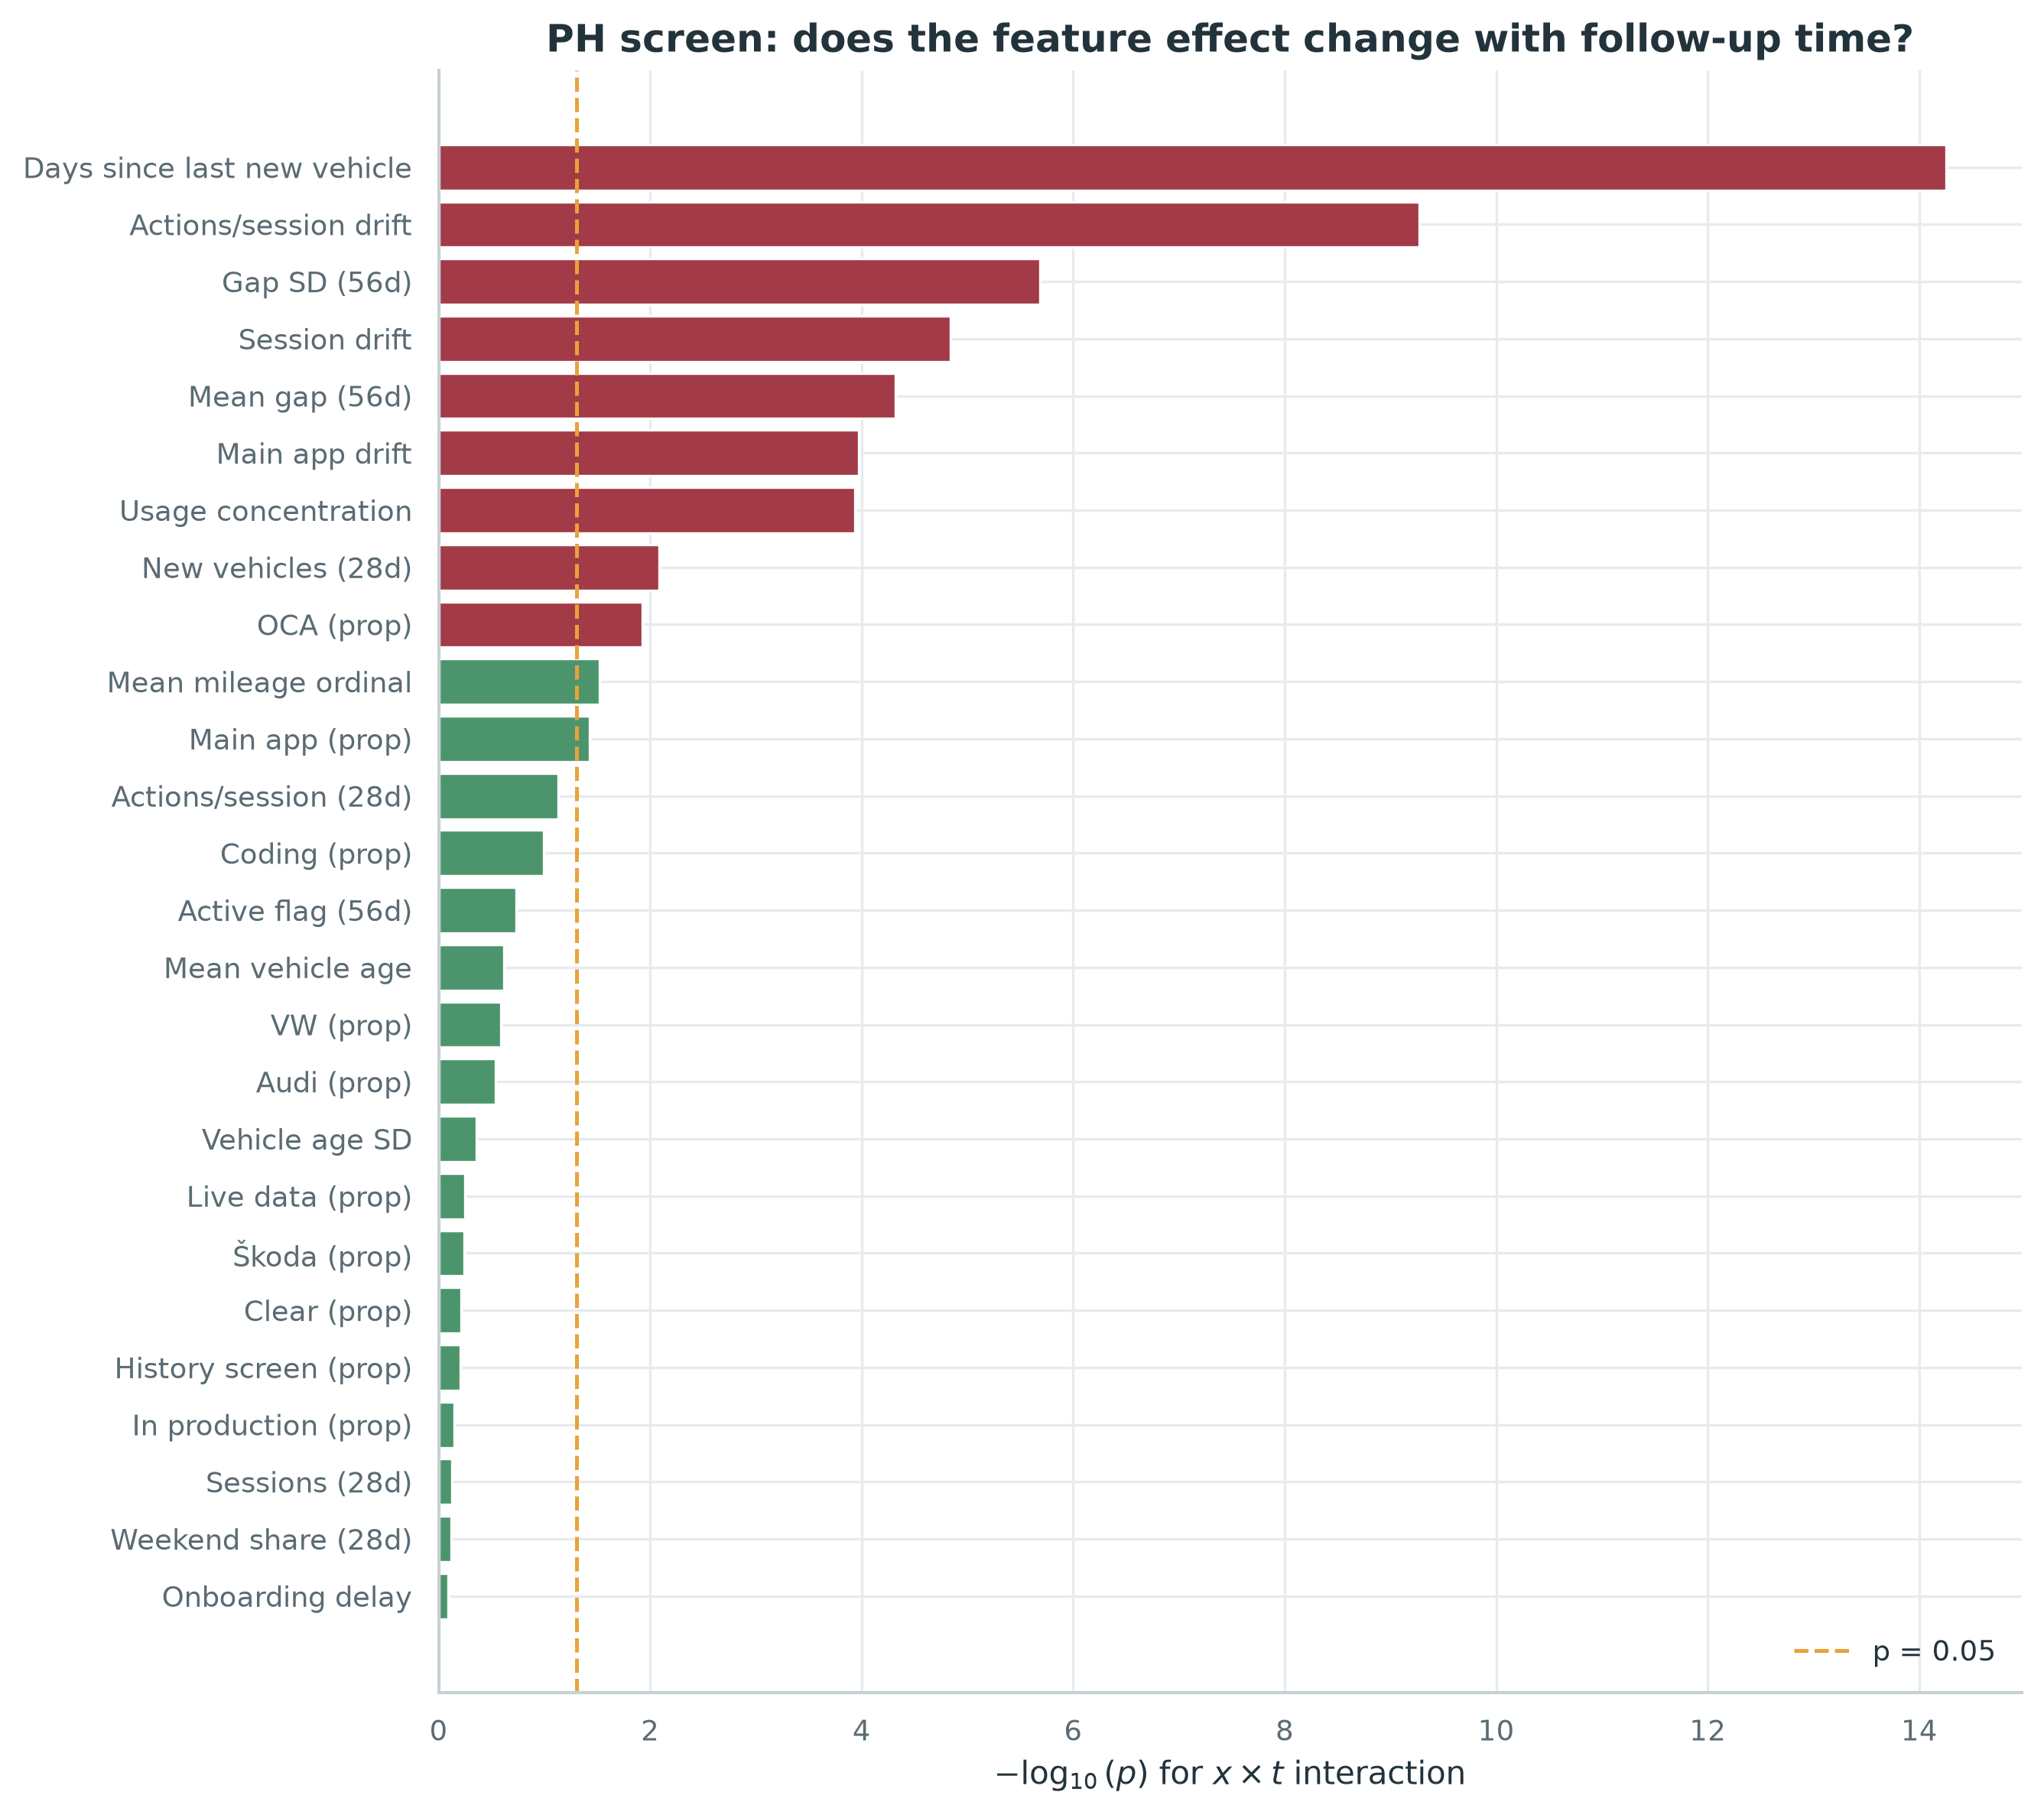

Significant x×t at raw p<0.05: 11/26
Significant x×t after BH FDR:   9/26
BH-flagged: Days since last new vehicle, Actions/session drift, Gap SD (56d), Session drift, Mean gap (56d), Main app drift, Usage concentration, New vehicles (28d), OCA (prop)


In [9]:
plot_df = ph_tests.sort_values("p_x_t", ascending=True).copy()
plot_df["neglog10_p"] = -np.log10(plot_df["p_x_t"].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(9, 8))
colors = [
    style.COLORS["highlight"] if flag else style.PALETTE["Personal"]
    for flag in plot_df["flag_bh_05"]
]
ax.barh(plot_df["label"], plot_df["neglog10_p"], color=colors)
ax.axvline(-np.log10(0.05), color=style.COLORS["accent"], ls="--", lw=1.2, label="p = 0.05")
ax.set_xlabel(r"$-\log_{10}(p)$ for $x \times t$ interaction")
ax.set_ylabel("")
ax.set_title("PH screen: does the feature effect change with follow-up time?")
ax.invert_yaxis()
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

n_raw = int(ph_tests["flag_raw_05"].sum())
n_bh = int(ph_tests["flag_bh_05"].sum())
print(f"Significant x×t at raw p<0.05: {n_raw}/{len(ph_tests)}")
print(f"Significant x×t after BH FDR:   {n_bh}/{len(ph_tests)}")
if n_bh:
    print("BH-flagged:", ", ".join(ph_tests.loc[ph_tests["flag_bh_05"], "label"]))

## 2. Coefficient paths across follow-up bins

Univariate `event ~ x` within early / mid / late bins. Flat lines support PH;
large swings flag the same features as the interaction tests.

                   n  events
period                      
early (0–84d)  36559    1041
mid (84–196d)  38288    1145
late (196d+)   69080    1042


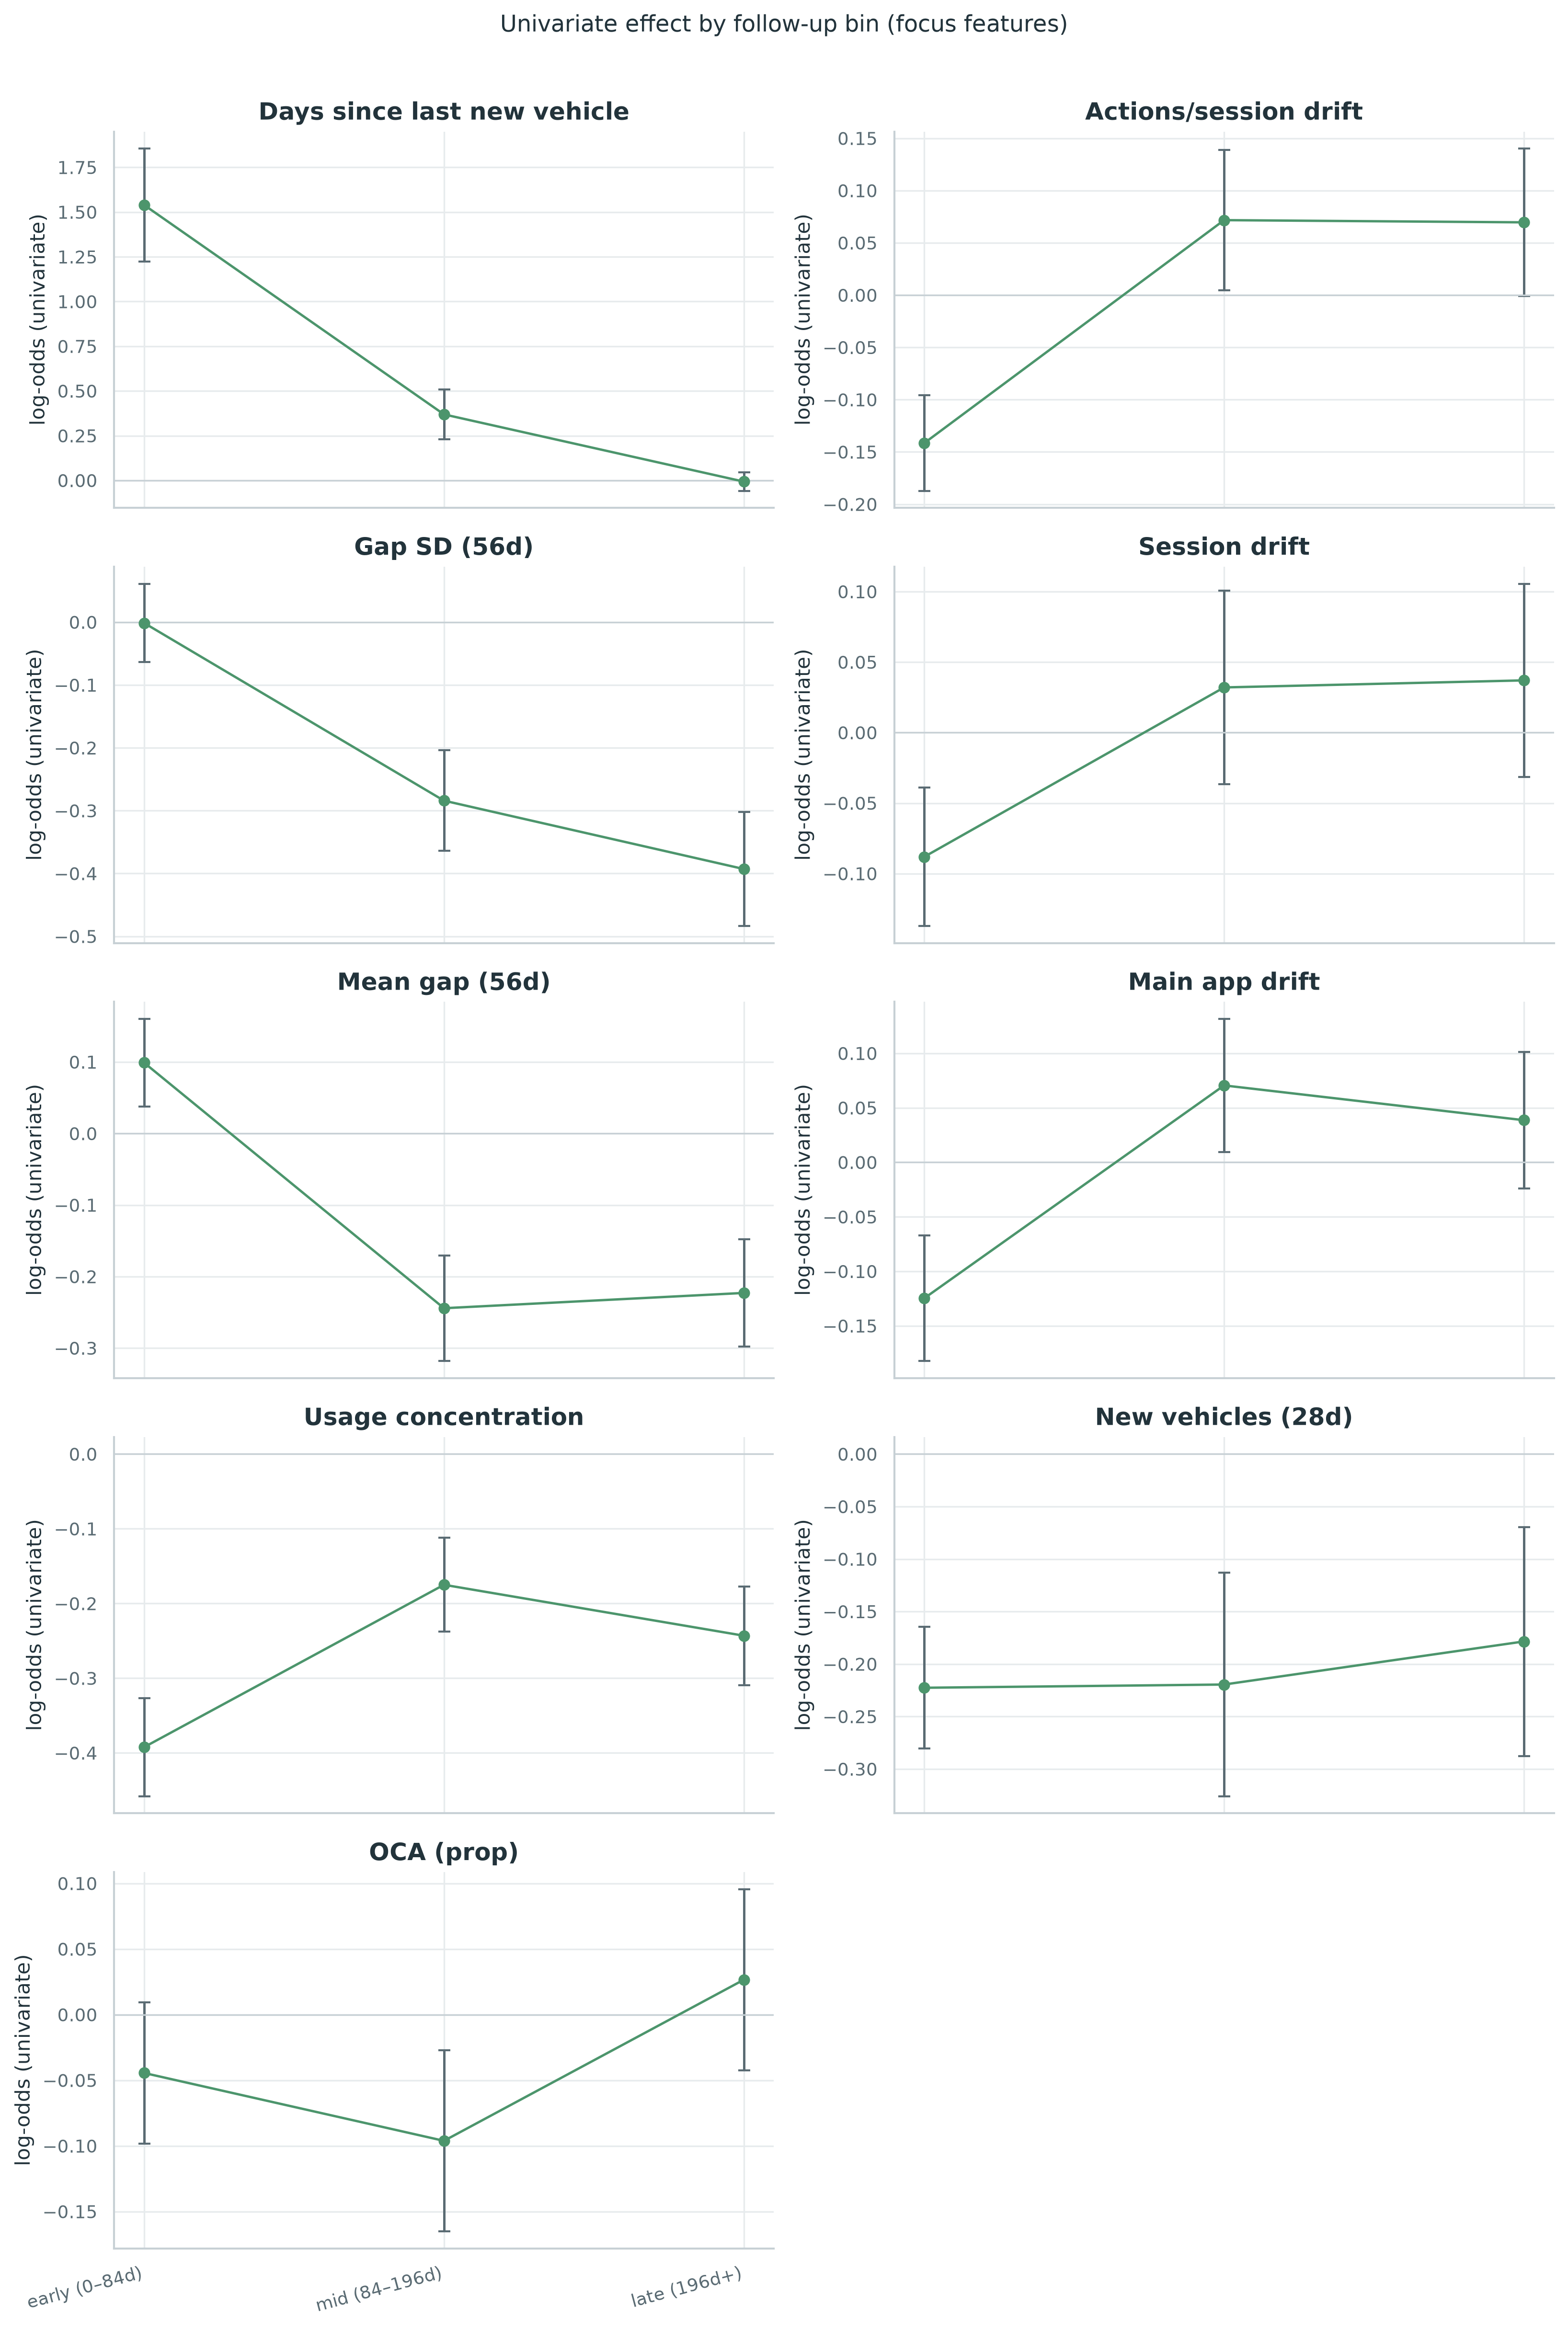

In [10]:
import warnings

df["period"] = pd.cut(
    df["interval_start"],
    bins=TIME_BINS,
    right=False,
    labels=TIME_LABELS,
)

bin_rows = []
for period, g in df.groupby("period", observed=True):
    y_g = g["event"].to_numpy()
    if y_g.sum() < 20 or (1 - y_g).sum() < 20:
        continue
    for col in feature_cols:
        x = Xs.loc[g.index, col].to_numpy()
        if np.nanstd(x) < 1e-8:
            continue
        mat = sm.add_constant(x)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit = sm.Logit(y_g, mat).fit(disp=0, maxiter=200, method="lbfgs")
        # Drop separated / non-converged fits (unstable SE and absurd |beta|)
        if not fit.mle_retvals.get("converged", False):
            continue
        if not np.isfinite(fit.params[1]) or abs(fit.params[1]) > 10:
            continue
        if not np.isfinite(fit.bse[1]) or fit.bse[1] > 5:
            continue
        bin_rows.append(
            {
                "period": str(period),
                "feature": col,
                "label": vg.pretty_new_features.get(col, col),
                "beta": fit.params[1],
                "se": fit.bse[1],
            }
        )

bin_coefs = pd.DataFrame(bin_rows)
print(df.groupby("period", observed=True).agg(n=("event", "size"), events=("event", "sum")))

# Plot BH-flagged features if any; otherwise the 8 smallest interaction p-values
focus = ph_tests.loc[ph_tests["flag_bh_05"], "feature"].tolist()
if not focus:
    focus = ph_tests.nsmallest(8, "p_x_t")["feature"].tolist()

plot_coefs = bin_coefs[bin_coefs["feature"].isin(focus)].copy()
counts = plot_coefs.groupby("feature")["period"].nunique()
stable = counts[counts >= len(TIME_LABELS)].index.tolist()
if stable:
    plot_coefs = plot_coefs[plot_coefs["feature"].isin(stable)]
    focus = [f for f in focus if f in stable]
period_order = [lab for lab in TIME_LABELS if lab in set(plot_coefs["period"])]

n_feat = plot_coefs["feature"].nunique()
if n_feat == 0:
    print("No stable bin-wise coefficients to plot for the focus features.")
else:
    n_cols = 2
    n_rows = int(np.ceil(n_feat / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 3.2 * n_rows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, feat in zip(axes, focus):
        g = plot_coefs[plot_coefs["feature"] == feat]
        if g.empty:
            ax.set_visible(False)
            continue
        g = g.set_index("period").reindex(period_order)
        ax.errorbar(
            range(len(period_order)),
            g["beta"],
            yerr=1.96 * g["se"],
            fmt="-o",
            color=style.PALETTE["Personal"],
            ecolor=style.COLORS["secondary_text"],
            capsize=3,
        )
        ax.axhline(0, color=style.COLORS["axis"], lw=0.8)
        ax.set_xticks(range(len(period_order)), period_order, rotation=15, ha="right")
        ax.set_title(vg.pretty_new_features.get(feat, feat))
        ax.set_ylabel("log-odds (univariate)")

    for ax in axes[len(focus):]:
        ax.set_visible(False)

    fig.suptitle("Univariate effect by follow-up bin (focus features)", y=1.01)
    plt.tight_layout()
    plt.show()


## 3. Multivariate Cox Schoenfeld-residual screen

The earlier interaction tests are deliberately univariate. This section fits the joint counting-process Cox model with `statsmodels.PHReg`, then tests whether each **scaled Schoenfeld residual** trends with ranked event time.

`account_tenure_days` is omitted because it is exactly equal to `interval_end + onboarding_delay_days`. At any Cox risk set, `interval_end` is fixed and absorbed by the baseline hazard, so account tenure and onboarding delay are not jointly identifiable. Retaining both makes the information matrix singular.

In [11]:
from scipy import stats
from statsmodels.duration.hazard_regression import PHReg

# Exact dependency that prevents a joint Cox fit with both tenure variables
identity_error = (
    df["account_tenure_days"]
    - (df["interval_end"] + df["onboarding_delay_days"])
).abs().max()
assert identity_error == 0

cox_features = list(feature_cols)
X_cox = Xs[cox_features]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cox_fit = PHReg(
        endog=df["interval_end"].to_numpy(dtype=float),
        exog=X_cox.to_numpy(),
        status=y,
        entry=df["interval_start"].to_numpy(dtype=float),
        ties="efron",
    ).fit(disp=0)

assert np.isfinite(cox_fit.params).all()
event_mask = y == 1
schoenfeld = np.asarray(cox_fit.schoenfeld_residuals)[event_mask]
# Multiplication by the coefficient covariance accounts for covariance among terms;
# an overall constant would not affect the trend tests below.
scaled_schoenfeld = schoenfeld @ np.asarray(cox_fit.cov_params())
event_time_rank = stats.rankdata(
    df.loc[event_mask, "interval_end"].to_numpy(dtype=float)
)

rows = []
for j, col in enumerate(cox_features):
    slope, intercept, r_value, p_value, slope_se = stats.linregress(
        event_time_rank, scaled_schoenfeld[:, j]
    )
    rows.append(
        {
            "feature": col,
            "label": vg.pretty_new_features.get(col, col),
            "time_correlation": r_value,
            "p_schoenfeld": p_value,
        }
    )

cox_ph_tests = pd.DataFrame(rows).sort_values("p_schoenfeld").reset_index(drop=True)
cox_ph_tests["p_bh"] = multipletests(
    cox_ph_tests["p_schoenfeld"], method="fdr_bh"
)[1]
cox_ph_tests["flag_raw_05"] = cox_ph_tests["p_schoenfeld"] < 0.05
cox_ph_tests["flag_bh_05"] = cox_ph_tests["p_bh"] < 0.05

display(
    cox_ph_tests[
        ["label", "feature", "time_correlation", "p_schoenfeld", "p_bh", "flag_bh_05"]
    ].style.format(
        {
            "time_correlation": "{:.3f}",
            "p_schoenfeld": "{:.4f}",
            "p_bh": "{:.4f}",
        }
    )
)

print(f"Raw p<0.05: {(cox_ph_tests['flag_raw_05']).sum()}/{len(cox_ph_tests)}")
print(f"BH FDR<0.05: {(cox_ph_tests['flag_bh_05']).sum()}/{len(cox_ph_tests)}")

,label,feature,time_correlation,p_schoenfeld,p_bh,flag_bh_05
0,New vehicles (28d),n_new_vehicles_0_28_days,-0.054,0.0020,0.0349,True
1,Main app (prop),prop_main_0_56,-0.053,0.0027,0.0349,True
2,Usage concentration,usage_concentration,0.048,0.0069,0.0598,False
3,Active flag (56d),active_flag_0_56_days,-0.043,0.0152,0.0932,False
4,Vehicle age SD,vehicle_age_sd_overall,0.042,0.0179,0.0932,False
5,Session drift,sessions_intensity_drift_0_28_vs_28_56_days,-0.040,0.0245,0.1060,False
6,Main app drift,prop_main_drift_0_28_vs_28_56,-0.038,0.0289,0.1075,False
7,Days since last new vehicle,days_since_last_new_vehicle,0.036,0.0400,0.1298,False
8,Live data (prop),prop_live_data_0_56,0.024,0.1641,0.4741,False
9,Actions/session (28d),actions_per_session_0_28_days,-0.023,0.1922,0.4763,False


Raw p<0.05: 8/26
BH FDR<0.05: 2/26


## Read-out

- **BH-non-significant `x:t`**: no strong evidence that that feature’s effect drifts with time (PH-compatible in this screen).
- **BH-significant `x:t`**: effect appears time-dependent — consider time interactions, stratification, or a non-PH model in R; confirm with `cox.zph` on the fitted Cox.
- This screen is **univariate** (plus a linear time main effect). Collinearity and joint confounding can still shift multivariate Cox PH diagnostics.

In [14]:
df.columns

Index(['user_id', 'interval_start', 'interval_end', 'prop_clear_0_56',
       'prop_coding_0_56', 'prop_history_screen_0_56', 'prop_live_data_0_56',
       'prop_oca_0_56', 'prop_scan_0_56', 'prop_main_0_56',
       'prop_main_drift_0_28_vs_28_56', 'n_sessions_0_28_days',
       'sessions_intensity_drift_0_28_vs_28_56_days',
       'actions_per_session_0_28_days',
       'actions_per_session_intensity_drift_0_28_vs_28_56_days', 'recency',
       'weekend_share_0_28_days', 'usage_concentration',
       'vehicle_mean_age_overall', 'vehicle_age_sd_overall', 'prop_in_prod',
       'vehicle_mean_mileage_ordinal', 'n_new_vehicles_0_28_days',
       'days_since_last_new_vehicle', 'overall_prop_vehicle_make_audi',
       'overall_prop_vehicle_make_skoda',
       'overall_prop_vehicle_make_volkswagen', 'churn_triggered_adjusted',
       'active_flag_0_56_days', 'CV_gap_0_56_days', 'mean_gap_0_56_days',
       'sd_gap_0_56_days', 'account_tenure_days', 'onboarding_delay_days',
       'event', 'p